In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, PredictionErrorDisplay
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv("US_House_price.csv")
df

,DATE,building_permits,const_price_index,delinquency_rate,GDP,house_for_sale_or_sold,housing_subsidies,income,interest_rate,mortgage_rate,construction_unit,total_houses,total_const_spending,unemployment_rate,urban_population,home_price_index
0,2003-01-01,1808,144.400,1.97,14614.141,76,25.930,10710.4,1.24,5.9160,1654,111278.0,1.5,5.8,79.583,128.461
1,2003-02-01,1854,145.200,1.97,14614.141,82,25.930,10674.0,1.26,5.8425,1688,111278.0,-0.1,5.9,79.583,129.355
2,2003-03-01,1757,145.200,1.97,14614.141,98,25.930,10696.5,1.25,5.7450,1638,111278.0,-1.1,5.9,79.583,130.148
3,2003-04-01,1803,145.900,1.83,14743.567,91,25.930,10752.7,1.26,5.8125,1662,111278.0,1.7,6.0,79.583,130.884
4,2003-05-01,1835,145.800,1.83,14743.567,101,25.930,10832.0,1.26,5.4840,1733,111278.0,0.2,6.1,79.583,131.735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2022-08-01,1586,342.753,1.85,21851.134,51,48.021,16161.4,2.33,5.2225,1355,131202.0,-2.4,3.7,83.084,301.596
236,2022-09-01,1588,336.464,1.85,21851.134,44,48.021,16184.9,2.56,6.1120,1438,131202.0,-1.8,3.5,83.084,299.380
237,2022-10-01,1555,333.796,1.78,21989.981,43,48.021,16223.5,3.08,6.9000,1348,131202.0,-1.5,3.7,83.084,298.922
238,2022-11-01,1402,330.369,1.78,21989.981,41,48.021,16229.6,3.78,6.8050,1543,131202.0,-1.4,3.6,83.084,298.312


In [72]:
df['year'] = pd.to_datetime(df['DATE']).dt.year
df.drop(columns=['DATE','year'], inplace=True)

In [73]:
print("Shape of dataset:", df.shape) 

Shape of dataset: (240, 15)


In [74]:
print("\nColumns in dataset:", df.columns)


Columns in dataset: Index(['building_permits', 'const_price_index', 'delinquency_rate', 'GDP',
       'house_for_sale_or_sold', 'housing_subsidies', 'income',
       'interest_rate', 'mortgage_rate', 'construction_unit', 'total_houses',
       'total_const_spending', 'unemployment_rate', 'urban_population',
       'home_price_index'],
      dtype='object')


In [75]:
print("\nDataset info:")
df.info()    


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   building_permits        240 non-null    int64  
 1   const_price_index       240 non-null    float64
 2   delinquency_rate        240 non-null    float64
 3   GDP                     240 non-null    float64
 4   house_for_sale_or_sold  240 non-null    int64  
 5   housing_subsidies       240 non-null    float64
 6   income                  240 non-null    float64
 7   interest_rate           240 non-null    float64
 8   mortgage_rate           240 non-null    float64
 9   construction_unit       240 non-null    int64  
 10  total_houses            240 non-null    float64
 11  total_const_spending    240 non-null    float64
 12  unemployment_rate       240 non-null    float64
 13  urban_population        240 non-null    float64
 14  home_price_index        240

In [76]:
print("\nStatistical summary:")
print(df.describe())  


Statistical summary:
       building_permits  const_price_index  delinquency_rate           GDP  \
count        240.000000         240.000000        240.000000    240.000000   
mean        1309.350000         212.851467          4.876750  18095.159938   
std          479.881055          44.566715          3.305235   2002.293963   
min          513.000000         144.400000          1.410000  14614.141000   
25%          979.000000         184.275000          2.087500  16547.088000   
50%         1285.500000         207.450000          3.525000  17576.126000   
75%         1685.000000         224.525000          7.830000  19716.162500   
max         2263.000000         353.015000         11.480000  21989.981000   

       house_for_sale_or_sold  housing_subsidies        income  interest_rate  \
count              240.000000         240.000000    240.000000     240.000000   
mean                55.550000          34.677450  13493.480833       1.301625   
std                 25.383865   

In [77]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
building_permits          0
const_price_index         0
delinquency_rate          0
GDP                       0
house_for_sale_or_sold    0
housing_subsidies         0
income                    0
interest_rate             0
mortgage_rate             0
construction_unit         0
total_houses              0
total_const_spending      0
unemployment_rate         0
urban_population          0
home_price_index          0
dtype: int64


In [78]:
X = df.drop('home_price_index', axis=1)
y = df['home_price_index']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [80]:
lr = LinearRegression()

# Cross-validation for Linear Regression
cv_scores_lr = cross_val_score(lr, X, y, cv=5)
print("Linear Regression - CV Scores:", cv_scores_lr)
print("Linear Regression - Mean CV Score:", cv_scores_lr.mean())

# Train & evaluate
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

Linear Regression - CV Scores: [-0.97931773  0.15884031 -0.07265137  0.79094305  0.43691196]
Linear Regression - Mean CV Score: 0.06694524498635157


# Decision Tree Regressor

In [81]:
dt = DecisionTreeRegressor(random_state=42)

# Cross-validation for Decision Tree
cv_scores_dt = cross_val_score(dt, X, y, cv=5)
print("\nDecision Tree - CV Scores:", cv_scores_dt)
print("Decision Tree - Mean CV Score:", cv_scores_dt.mean())

# Train & evaluate
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)


Decision Tree - CV Scores: [-1.53109937  0.30443294 -2.98824512 -6.38831251 -2.1843299 ]
Decision Tree - Mean CV Score: -2.5575107917359006


# Random Forest Regressor

In [82]:
rf = RandomForestRegressor(random_state=42, n_estimators=100)

# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf, X, y, cv=5)
print("\nRandom Forest - CV Scores:", cv_scores_rf)
print("Random Forest - Mean CV Score:", cv_scores_rf.mean())

# Train & evaluate
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)


Random Forest - CV Scores: [-0.53037474  0.56110754 -1.10314842  0.58379674 -2.48362663]
Random Forest - Mean CV Score: -0.594449103426619


In [83]:
print("\n=== Model Performance Summary ===")
print(f"Linear Regression - MSE: {mse_lr:.4f}, R²: {r2_lr:.4f}")
print(f"Decision Tree     - MSE: {mse_dt:.4f}, R²: {r2_dt:.4f}")
print(f"Random Forest     - MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")


=== Model Performance Summary ===
Linear Regression - MSE: 19.4120, R²: 0.9919
Decision Tree     - MSE: 32.4466, R²: 0.9864
Random Forest     - MSE: 4.8657, R²: 0.9980


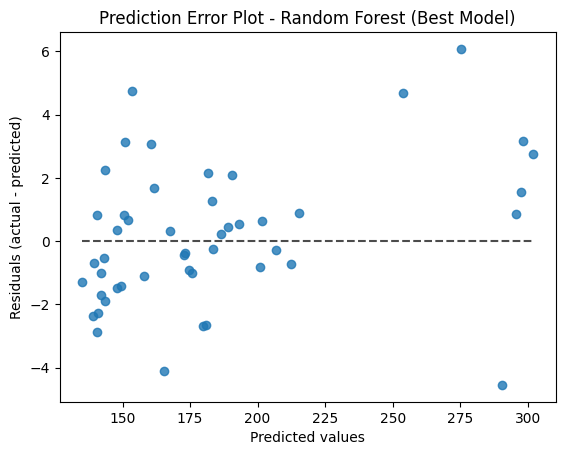

In [84]:
display = PredictionErrorDisplay(y_true=y_test, y_pred=y_pred_rf)
display.plot()
plt.title("Prediction Error Plot - Random Forest (Best Model)")
plt.show()


In [85]:
import pickle
#save the model
filename='construction_price.sav'
pickle.dump(model, open(filename,'wb'))
load_model=pickle.load(open(filename,'rb'))

In [86]:
load_model.predict([[2139,168.6,1.42,15844.727,92,27.651,11226.5,2.28,5.7100,1892,113343.0,1.6,5.3,79.928]])

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([165.30627321])